<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Hands_On_Minggu_4_STA1542_Eksplorasi_Data_Deret_Waktu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> EKSPLORASI DERET WAKTU  </center></h1><center>Laily Nissa A.M </center>

<center>
_____________________________________________________________________________________________________________________________
</center>


In [2]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=7d38b3706e622ceaa7dd1d2412b9e2810e86b2d5e399f9da0e17a7c7a359ed47
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

initiated datasets repo at: /root/.pydataset/


## Ilustrasi Data Empiris 1

Contoh data empiris pertama adalah indeks rata-rata bulanan osilasi Atlantik Utara (NAO) sejak Januari 1950 sampai Februari 2024. Indeks NAO penting untuk penelitian cuaca dan didasarkan pada perbedaan tekanan permukaan laut antara subtropis (Azores) yang tinggi dan subkutub rendah.

In [4]:
link = "https://ftp.cpc.ncep.noaa.gov/cwlinks/norm.daily.nao.cdas.z500.19500101_current.csv"
nao=pd.read_csv(link)

In [5]:
#melihat struktur data
nao.dtypes

,0
year,int64
month,int64
day,int64
nao_index_cdas,float64


In [6]:
# melihat 5 data pertama
nao.head()

,year,month,day,nao_index_cdas
0,1950,1,1,0.365
1,1950,1,2,0.096
2,1950,1,3,-0.416
3,1950,1,4,-0.616
4,1950,1,5,-0.261


In [7]:
#melihat 5 data terakhir
nao.tail()

,year,month,day,nao_index_cdas
28011,2026,9,10,0.923738
28012,2026,9,11,0.559008
28013,2026,9,12,0.548835
28014,2026,9,13,0.749521
28015,2026,9,14,0.773236


In [8]:
#cek missing values
nao.isnull().sum()

,0
year,0
month,0
day,0
nao_index_cdas,2


terdapat 2 nilai amaan yang kosong atau NA

In [9]:
import numpy as np

In [10]:
#mendapatkan indeks amatan yang missing values
np.where(nao.isnull())[0]

array([20752, 20844])

In [11]:
nao.iloc[[20752,20844],:]

,year,month,day,nao_index_cdas
20752,2006,10,26,NaN
20844,2007,1,26,NaN


In [12]:
#imputasi missing values dengan angka 0
nao.fillna(0,inplace=True)

In [13]:
nao.isnull().sum()

,0
year,0
month,0
day,0
nao_index_cdas,0


In [14]:
# Mengubah kolom year, month, dan day menjadi tipe data integer
nao['year'] = nao['year'].astype(int)
nao['month'] = nao['month'].astype(int)
nao['day'] = nao['day'].astype(int)

# Membuat satu kolom baru bernama 'date' yang berisi kombinasi kolom year, month, dan day
nao['date'] = pd.to_datetime(nao[['year', 'month', 'day']])


In [15]:
nao.head()

,year,month,day,nao_index_cdas,date
0,1950,1,1,0.365,1950-01-01
1,1950,1,2,0.096,1950-01-02
2,1950,1,3,-0.416,1950-01-03
3,1950,1,4,-0.616,1950-01-04
4,1950,1,5,-0.261,1950-01-05


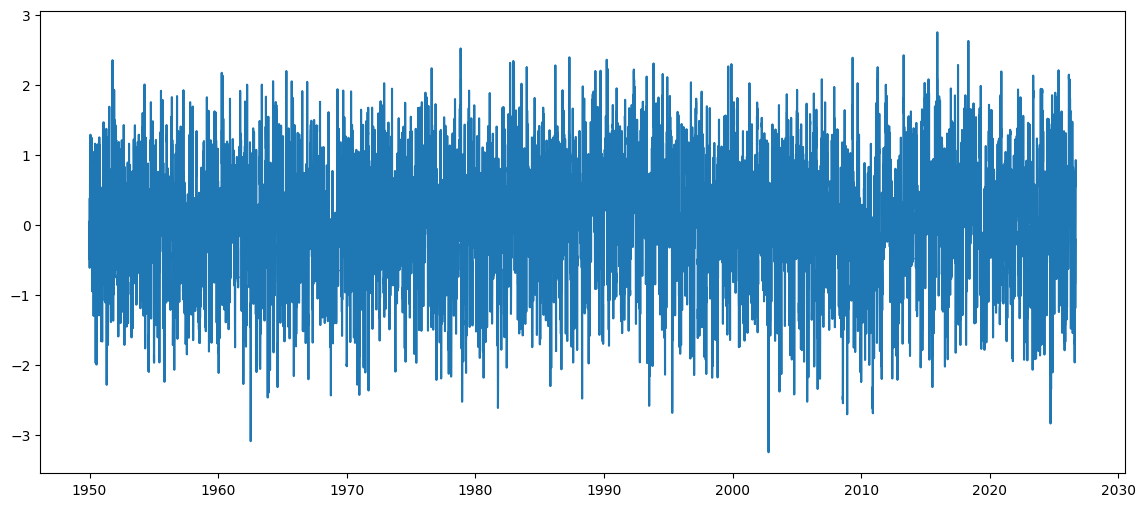

In [16]:
plt.figure(figsize=(14,6))
plt.plot(nao['date'],nao['nao_index_cdas']); plt.show()

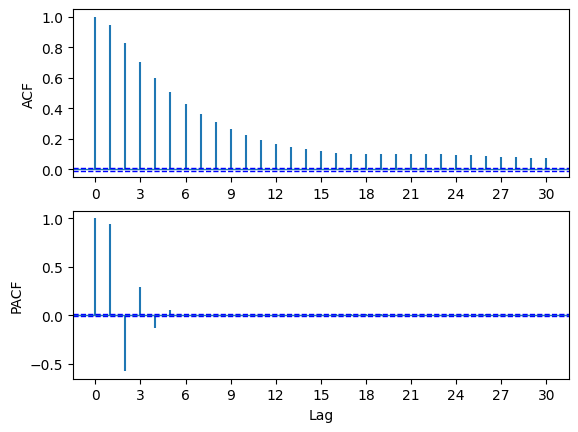

In [17]:
# membuat plot ACF dan PACF contoh dari data nao
acf_pacf_fig(nao['nao_index_cdas'], both=True, lag=30)

Berdasarkan plot ACF dan PACF contoh yang diperoleh apakah deret stasioner? Mengapa?

Selain berdasarkan plot deret, kestasioneran suatu deret dapat diperiksa menggunakan uji statistik, salah satunya adalah uji ADF. Hipotesis yang digunakan dalam uji ADF adalah

$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

In [18]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(nao['nao_index_cdas'])[1]

0.0

Bagaimana interpretasi hasil uji tersebut? Apakah interpretasi hasil uji sama dengan interpretasi dari plot deret maupun plot ACF?

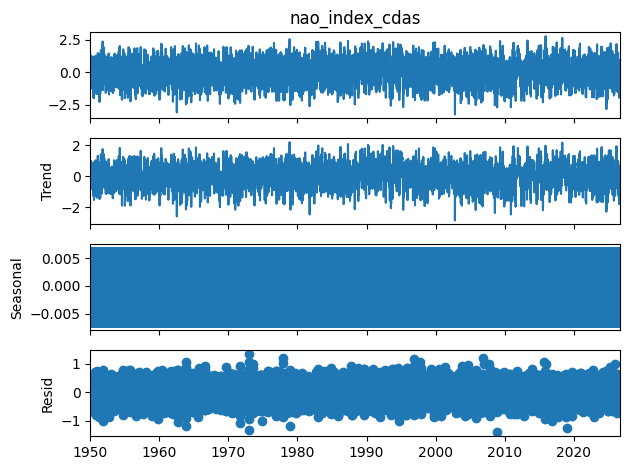

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
nao2=nao.set_index('date')
result = seasonal_decompose(nao2['nao_index_cdas'], model='additive')
result.plot()
plt.show()

Jika dilihat dari hasil dekomposisi tersebut apa interpretasi Anda? Bagaimana keterkaitan hasil dekomposisi dengan interpretasi Anda dari plot ACF dan uji ADF?

Jika dilihat berdasarkan plot deret apakah deret sudah stasioner dalam ragam?

Terdapat dua kestasioneran dalam deret waktu, yaitu kestasioneran dalam nilaitengah dan dalam ragam. Uji ADF hanya digunakan untuk menguji kestasioneran dalam nilaitengah, sementara untuk mengetahui kestasioneran deret dalam ragam dapat dicek melalui uji Boxcox. Jika nilai $\lambda=1$ atau angka 1 masuk dalam interval kepercayaan $\lambda$, maka dapat dikatakan bahwa deret sudah stasioner dalam ragam.

Dalam melakukan transformasi boxcox, perlu diperhatikan bahwa nilai deret harus positif semua. Jika ada nilai deret yang negatif ataupun nol maka deret harus ditransformasi agar nilainya menjadi positif.

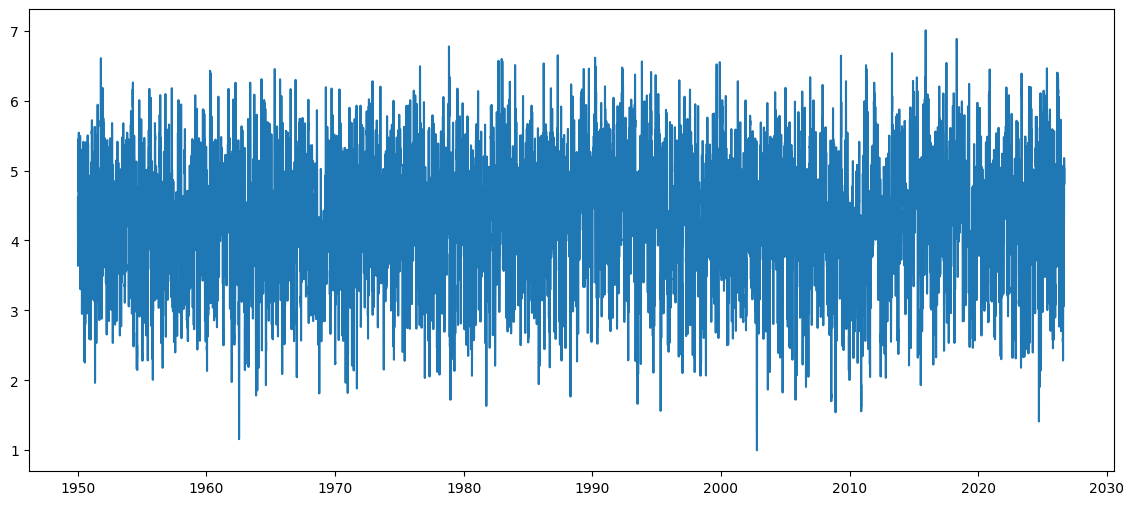

In [20]:
# Transformasi kolom 'nao_index_cdas' agar bernilai positif
nao['nao_index_cdas_positive'] = nao['nao_index_cdas'] - nao['nao_index_cdas'].min() + 1

# Plot data baru
plt.figure(figsize=(14,6))
plt.plot(nao['date'],nao['nao_index_cdas_positive']); plt.show()

In [21]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(nao['nao_index_cdas_positive'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  1.260244487466071
interval kepercayaan lambda: (1.2104450517269771, 1.3102187988924772)


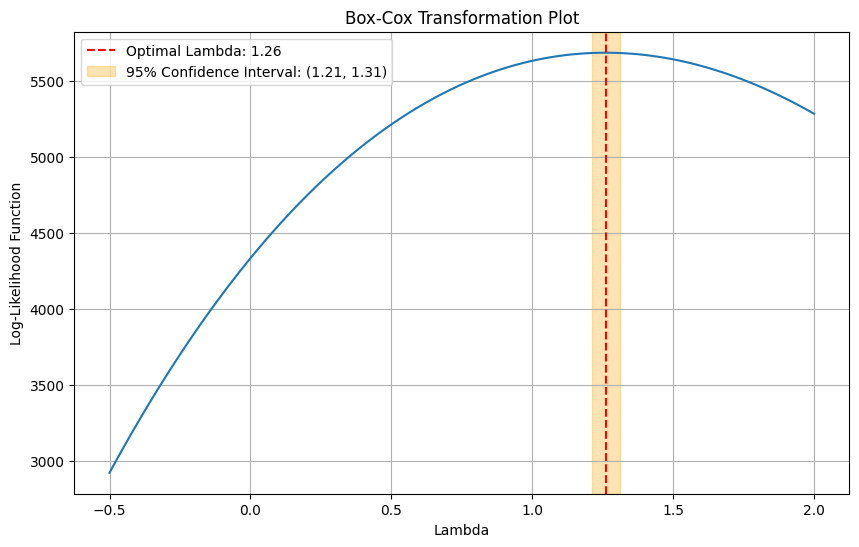

In [22]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, nao['nao_index_cdas_positive']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

Bagaimana interpretasi Anda dari nilai lambda yang diperoleh?

Misalkan data yang digunakan diagregasikan dari data harian menjadi data bulanan. (Disclaimer: Hal ini dilakukan hanya untuk tujuan eksplorasi, bukan suatu tahapan yang dilakukan untuk menangani suatu isu tertentu dalam deret waktu)

In [23]:
#agregasi data sebagai nilai rata-rata bulanan
naos=nao.groupby(['year','month'])['nao_index_cdas'].mean()

In [24]:
type(naos)

pandas.core.series.Series

In [25]:
timeindex=pd.date_range('1950-01', periods=len(naos),freq='M')

In [26]:
naos.index=timeindex

In [27]:
naos.head()

,nao_index_cdas
1950-01-31,0.463516
1950-02-28,0.420714
1950-03-31,0.008387
1950-04-30,0.239433
1950-05-31,-0.261226


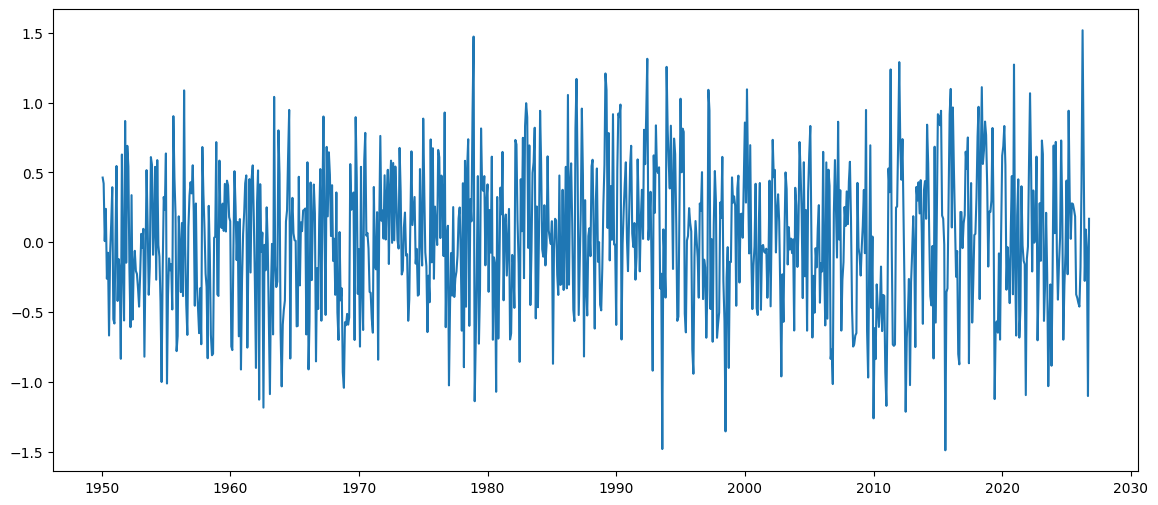

In [28]:
#plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(naos); plt.show()

Apa perbedaan yang dapat Anda temukan setelah data dilakukan agregasi bulanan?

In [29]:
#ringkasan statistika deret
naos.describe()

,nao_index_cdas
count,921.000000
mean,0.027440
std,0.511899
min,-1.490336
25%,-0.331484
50%,0.033097
75%,0.404114
max,1.518708


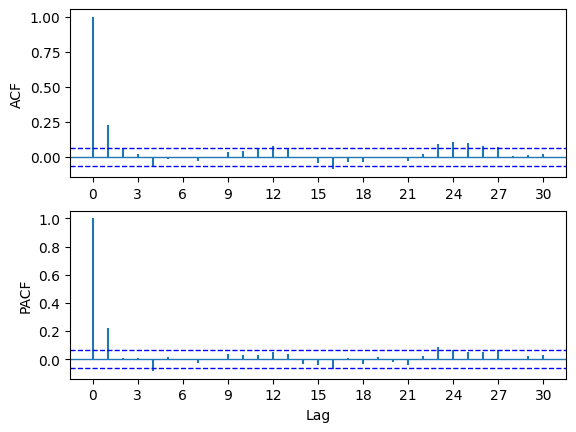

In [30]:
#plot acf dan pacf contoh
acf_pacf_fig(naos, both=True, lag=30); plt.show()

Bagaimana interpretasi Anda dari plot ACF dan PACF tersebut?

Alat lain yang dapat digunakan untuk memeriksa kestasioneran deret adalah uji Akar-Satuan.

Uji akar satuan yang pertama adalah uji akar-satuan Dickey Fuller (ADF test). Hipotesis yang digunakan dalam uji ADF adalah

$H_0:$ menyatakan deret tidak stasioner

$H_1:$ menyatakan deret stasioner.

In [31]:
from statsmodels.tsa.stattools import adfuller

In [32]:
adfuller(naos, autolag='AIC')[1]

5.865651117554439e-28

Karena p-value yang diperoleh kurang dari 0.05, dalam hal ini kita tolak $H_0$ sehingga kita yakin bahwa deret tersebut stasioner.

Uji akar-satuan yang lain adalah Kwiatkowski-Phillips-Schmidt-Shin (KPSS). Hipotesis dalam uji KPSS adalah

$H_0:$ deret stasioner

$H_1:$ deret tidak stasioner

In [33]:
sm.tsa.stattools.kpss(naos, regression="c", nlags=50)[1]

np.float64(0.1)

Karena p-value yang diperoleh lebih besar dari 0.05, dalam hal ini kita tidak tolak $H_0$ sehingga kita katakan bahwa deret tersebut stasioner.

Menguraikan deret waktu menjadi komponen-komponen penyusunnya terkadang juga membantu dalam proses eksplorasi deret. Secara umum suatu deret waktu terdiri atas 2 komponen, yaitu komponen sistematik dan non-sistematik.

Komponen sistematik adalah komponen yang bersifat konsisten dan berulang dalam deret. Komponen ini dapat dimodelkan. Komponen sistematik dari deret waktu terdiri dari komponen kecenderungan (trend) dan musiman (seasonality).

Sementara komponen non-sistematik adalah komponen acak dalam deret waktu yang tidak dapat dimodelkan secara langsung.

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

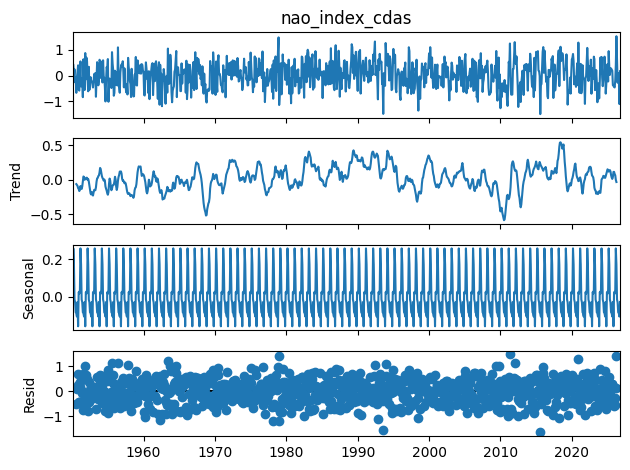

In [35]:
result = seasonal_decompose(naos, model='additive')
result.plot()
plt.show()

In [36]:
naos_positif = naos - naos.min() + 1

In [37]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(naos_positif, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  1.060290765404122
interval kepercayaan lambda: (0.7972791618507667, 1.3274635073577177)


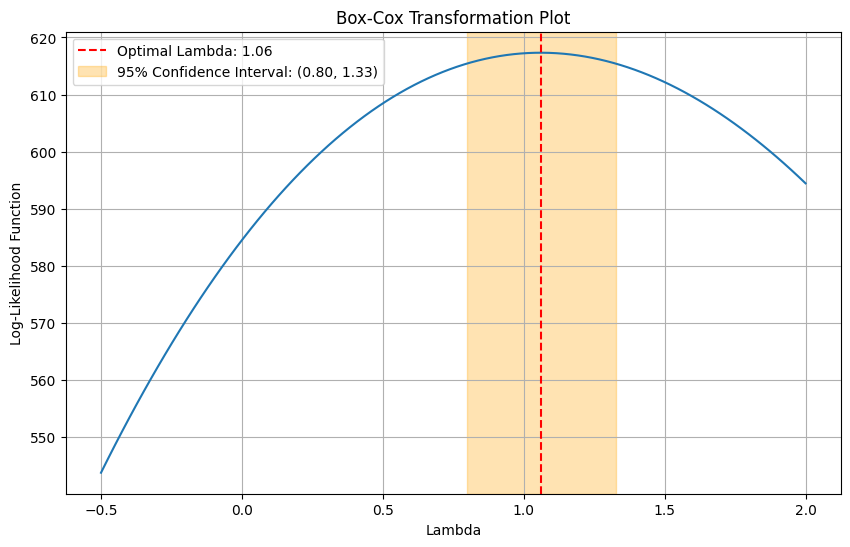

In [38]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, naos_positif) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

## Ilustrasi Data Empiris 2

Contoh data empiris kedua adalah deret rata-rata suhu tahunan di Hew Haven (dalam Fahrenheit) tahun 1912-1971.

In [39]:
from pydataset import data
nhtemp=data('nhtemp')

In [40]:
nhtemp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1 to 60
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    60 non-null     int64  
 1   nhtemp  60 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [41]:
nhtemp.head()

,time,nhtemp
1,1912,49.9
2,1913,52.3
3,1914,49.4
4,1915,51.1
5,1916,49.4


In [42]:
nhtemp['time'] = pd.date_range(start='1912', periods=len(nhtemp), freq='Y')
nhtemp.set_index('time', inplace=True)

In [43]:
nhtemp.head()

,nhtemp
time,
1912-12-31,49.9
1913-12-31,52.3
1914-12-31,49.4
1915-12-31,51.1
1916-12-31,49.4


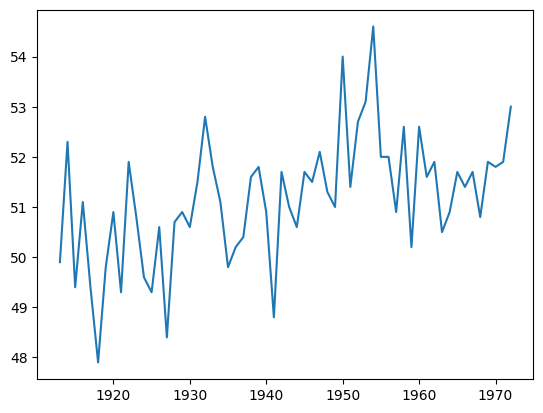

In [44]:
plt.plot(nhtemp); plt.show()

Berdasarkan plot apakah deret tampak stasioner?

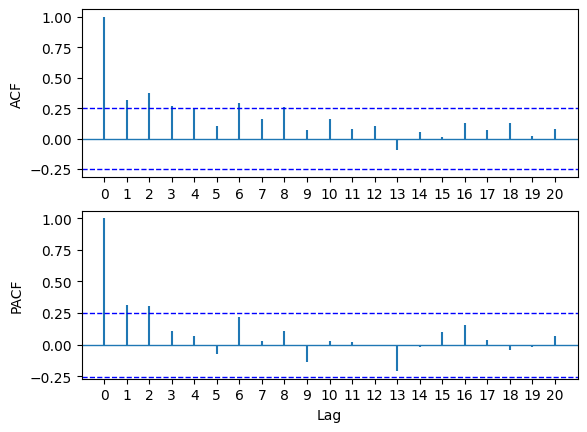

In [45]:
#plot acf dan pacf contoh
acf_pacf_fig(nhtemp, both=True, lag=20); plt.show()

In [46]:
adfuller(nhtemp, autolag='AIC')[1]

0.04270393882793662

In [47]:
sm.tsa.stattools.kpss(nhtemp['nhtemp'], regression="c", nlags=50)[1]

np.float64(0.06459064801389587)

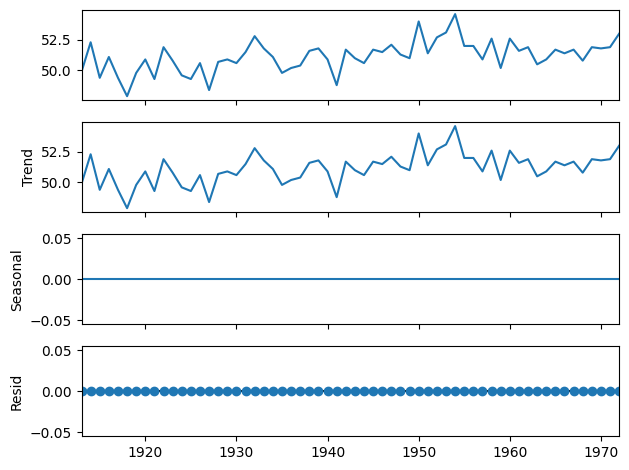

In [48]:
result = seasonal_decompose(nhtemp, model='additive')
result.plot()
plt.show()

In [49]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(nhtemp.nhtemp, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  1.8838880717167357
interval kepercayaan lambda: (-5.881049645767782, 9.544545267023773)


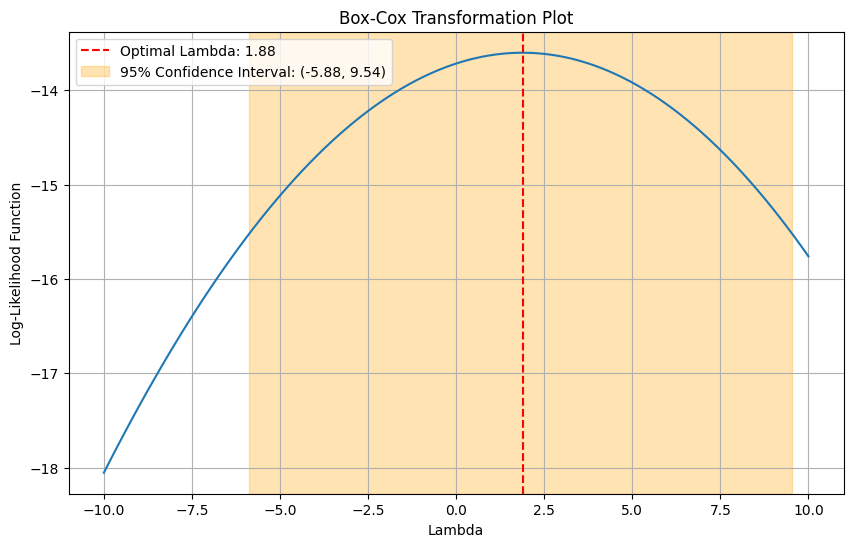

In [50]:
# Generate a range of lambda values
lambdas = np.linspace(-10, 10, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, nhtemp['nhtemp']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

Bagaimana interpretasi hasil dari plot ACF, dekomposisi, dan boxcox? Apakah semuanya mengarah pada deret yang stasioner?

## Ilustrasi Data Empiris 3

Perhatikan beberapa contoh deret waktu empiris berikut, yaitu indeks pasar saham DowJones, total produksi listrik USA, produksi gas Australia, dan pendapatan saham perusahan Johnson & Johnson.

In [51]:
import pydataset
djf=get_rdataset('DJFranses',package='AER').data
elec=get_rdataset('usmelec',package='fpp2').data
gas=get_rdataset('gas',package='forecast').data
johnson=pydataset.data('JohnsonJohnson')

In [52]:
def display_column_names(dataframe, name):
    print(f"Column names for {name}:")
    print(dataframe.columns.tolist())
    print("\n")

display_column_names(djf, 'djf')
display_column_names(elec, 'elec')
display_column_names(gas, 'gas')
display_column_names(johnson, 'johnson')

Column names for djf:
['time', 'value']


Column names for elec:
['time', 'value']


Column names for gas:
['time', 'value']


Column names for johnson:
['time', 'JohnsonJohnson']




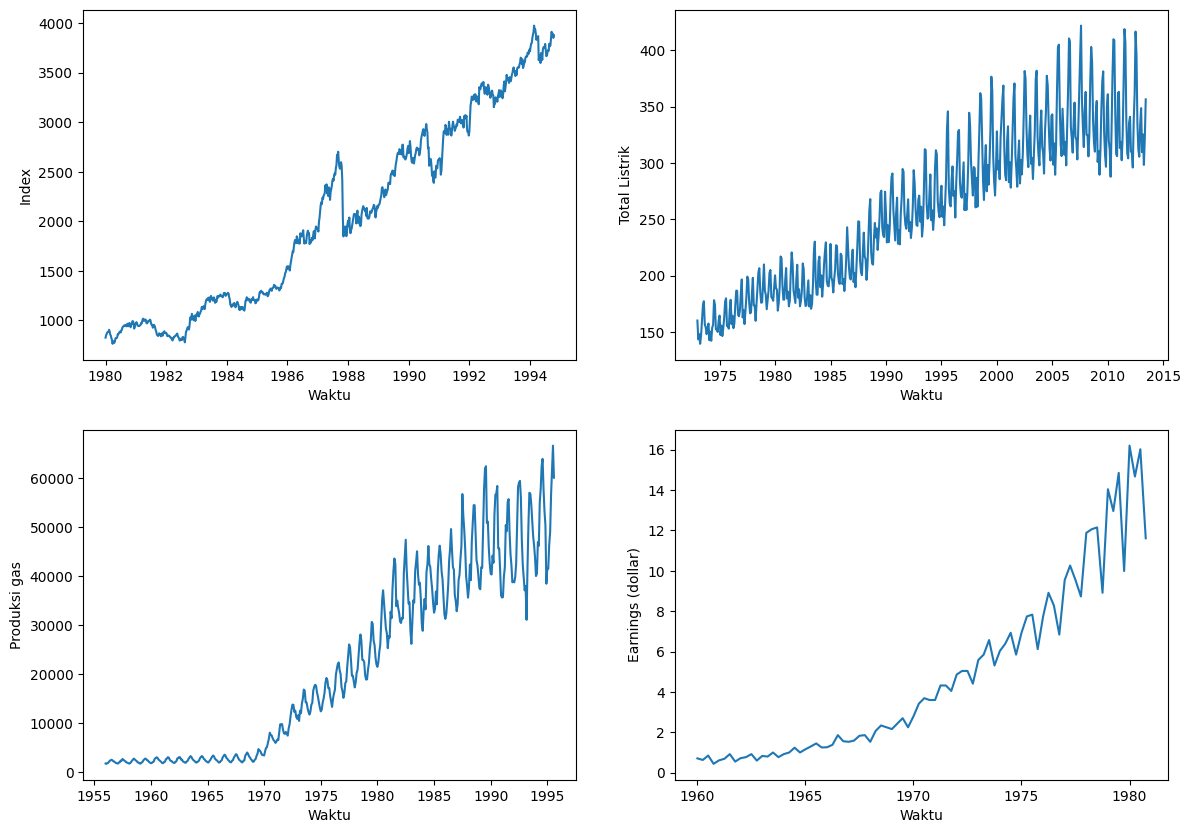

In [53]:
plt.figure(figsize=(14,10))
plt.subplot(221)
plt.plot(djf.time, djf.value)
plt.xlabel('Waktu'), plt.ylabel('Index')
plt.subplot(222)
plt.plot(elec.time, elec.value)
plt.xlabel('Waktu'), plt.ylabel('Total Listrik')
plt.subplot(223)
plt.plot(gas.time, gas.value)
plt.xlabel('Waktu'), plt.ylabel('Produksi gas')
plt.subplot(224)
plt.plot(johnson.time, johnson.JohnsonJohnson)
plt.xlabel('Waktu'), plt.ylabel('Earnings (dollar)')

plt.show()

Berdasarkan plot deret waktu dari data-data tersebut, insight apa yang Anda peroleh?

Empat data empiris di atas merupakan contoh deret waktu yang tidak stasioner. Perhatikan pola dari plot deret waktu yang tampak.

Dibandingkan dengan plot deret waktu dari 2 data empiris sebelumnya apa perbedaan yang terlihat?

Selanjutnya misalkan dieksplorasi lebih jauh deret produksi listrik bulanan di AS yang ditunjukkan oleh gambar kedua (baris 1 kolom 2).

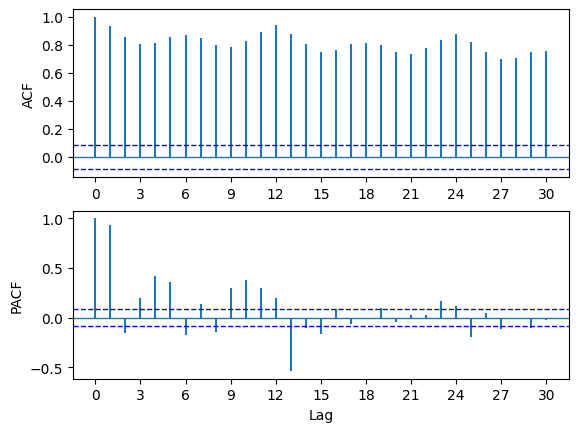

In [54]:
acf_pacf_fig(elec.value, both=True, lag=30)

Perhatikan plot ACF dan PACF yang diperoleh. Apa perbedaan pola ACF dan PACF tersebut dengan plot ACF dan PACF dari dua deret empiris pada ilustrasi sebelumnya?

In [55]:
from statsmodels.tsa.stattools import adfuller
adfuller(elec.value, autolag='AIC')[1]

0.5762353593662224

Nilai di atas merupakan *p-value* hasil uji akar satuan Dickey-Fuller. Karena **p-value yang diperoleh lebih besar dari 0.05**, dalam hal ini kita tidak tolak $H_0$ sehingga kita yakin bahwa deret tersebut **tidak stasioner**.

In [56]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(elec.value, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.4784891618659173
interval kepercayaan lambda: (0.12574071836904074, 0.8316106710351674)


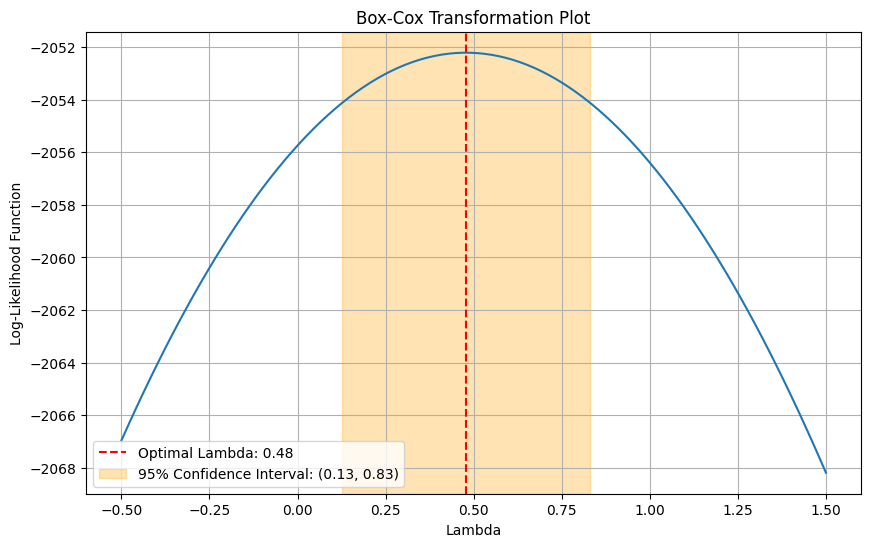

In [57]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 1.5, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, elec.value) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

Berdasarkan hasil box-cox apakah deret stasioner dalam ragam?

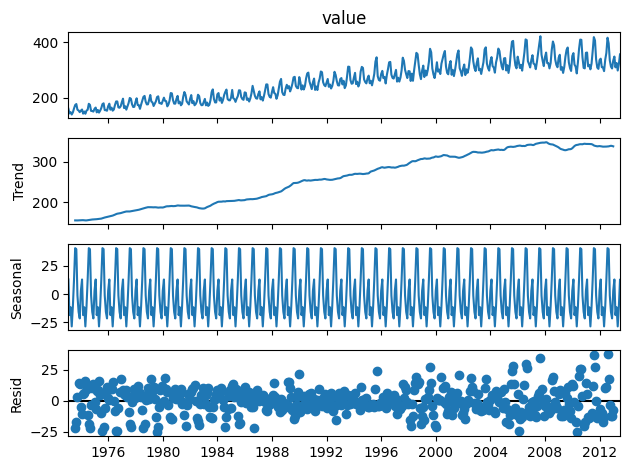

In [58]:
from statsmodels.tsa.seasonal import seasonal_decompose
elec['time'] = pd.date_range(start='1973', periods=len(elec), freq='M')
elec.set_index('time', inplace=True)
result = seasonal_decompose(elec.value, model='additive')
result.plot()
plt.show()

Insight apa dari hasil dekomposisi tersebut?

### Pembedaan (Differencing)

Diberikan model AR (1) dengan nilai $\phi=1$ yaitu:

<center> $Y_t=Y_{t-1}+e_t$ </center>

**pembedaan pertama** untuk suatu deret tersebut dinyatakan sebagai berikut:

<center> $\Delta Y_t=e_t$ </center>

dengan $\Delta Y_t=Y_t-Y_{t-1}$

Berdasarkan eksplorasi sebelumnya teridentifikasi bahwa deret produksi listrik AS tidak stasioner dalam nilaitengah. Selanjutnya dilakukan pembedaan satu kali terhadap deret produksi listrik.

In [59]:
# pembedaan/differencing ordo 1
elec_diff=elec.diff().dropna()

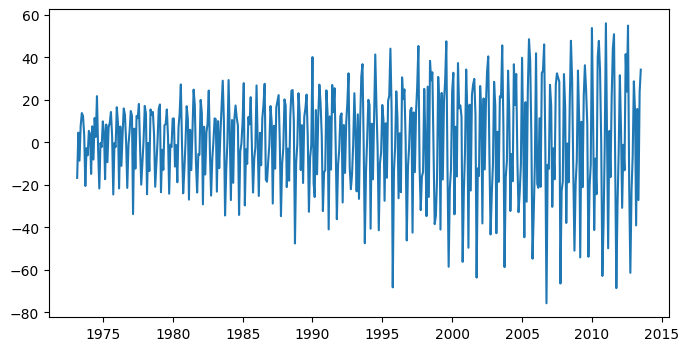

In [60]:
plt.figure(figsize=(8,4))
plt.plot(elec_diff)
plt.show()

Perhatikan plot hasil pembedaan sekali dari deret produksi listrik AS. Bagaimana pola deret?

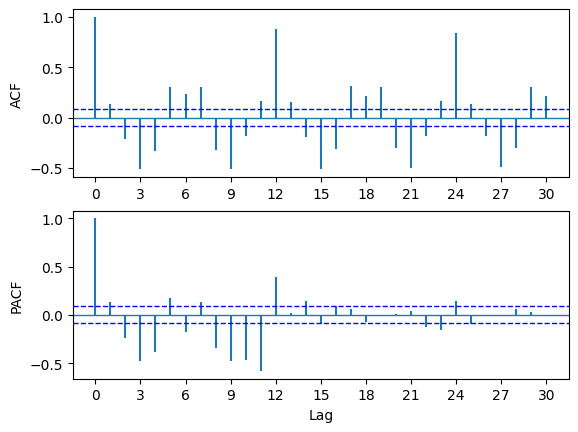

In [61]:
acf_pacf_fig(elec_diff, both=True, lag=30)

In [62]:
from statsmodels.tsa.stattools import adfuller
adfuller(elec_diff, autolag='AIC')[1]

9.267094557637156e-07

Berdasarkan plot ACF dan uji ADF terhadap deret hasil pembedaan satu kali diperoleh deret yang telah stasioner dalam nilaitengah.

In [63]:
elec_diff['positif'] = elec_diff['value'] - elec_diff['value'].min() + 1

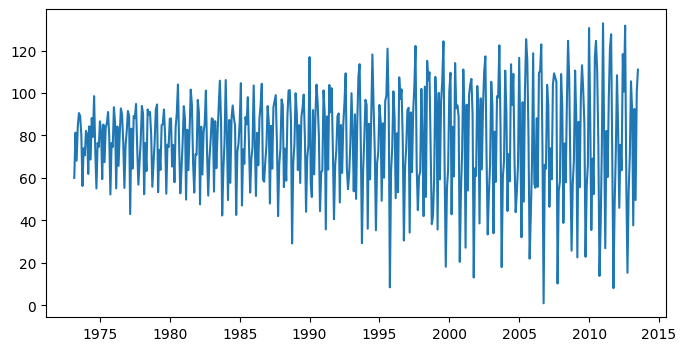

In [64]:
plt.figure(figsize=(8,4))
plt.plot(elec_diff.positif)
plt.show()

In [65]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(elec_diff.positif, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  1.2715690374447497
interval kepercayaan lambda: (1.0749404822390702, 1.4801789198613393)


Akan tetapi nilai ragam deret belum stasioner.

### Transformasi Boxcox

Transformasi Box-Cox atau transformasi pangkat digunakan untuk transformasi deret yang **tidak stasioner dalam ragam**. Transformasi Box-Cox didefinisikan sebagai berikut:

$g(x)=\frac{x^\lambda-1}{\lambda}\;\;\; untuk \lambda\ne 0$

$g(x)=\log x \;\;\; untuk \lambda=0$

Perhatikan jika 𝜆 = 1/2 maka menghasilkan transformasi akar kuadrat (jenis transformasi untuk nilai $\lambda$ yang lain dapat dilihat dalam Notodiputro et al 2025).

Transformasi pangkat hanya bisa diaplikasikan terhadap **data yang bernilai positif**. Jika terdapat nilai negatif atau nol, suatu konstanta positif dapat ditambahkan terhadap semua nilai data untuk memperoleh nilai data yang positif sebelum dilakukan transformasi pangkat.

Sebelumnya, hasil eksplorasi pada deret produksi listrik AS diperoleh nilai $\lambda$ optimum sebesar $0.47 \approx 0.5$, sehingga dapat digunakan transformasi akar kuadrat.

In [66]:
elec_sqrt=np.sqrt(elec.value)

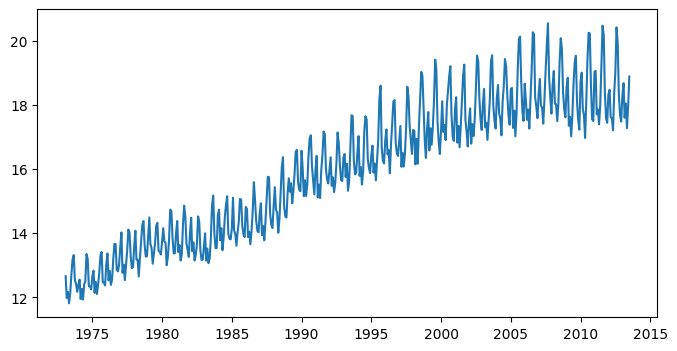

In [67]:
plt.figure(figsize=(8,4))
plt.plot(elec_sqrt)
plt.show()

In [68]:
data,lambda_fit,ci=boxcox(elec_sqrt, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.9569782575154432
interval kepercayaan lambda: (0.2514814367380965, 1.663221342070357)


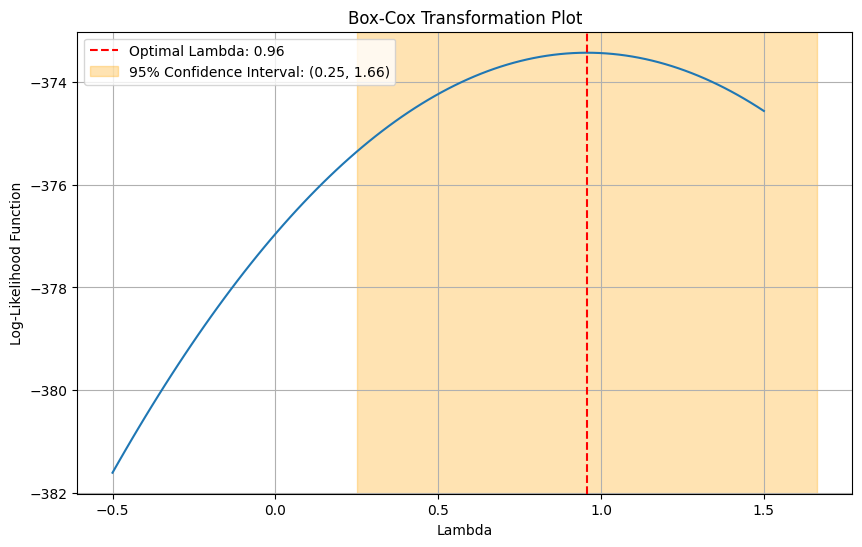

In [73]:
import numpy as np
#Generate a range of lambda values
lambdas = np.linspace(-0.5, 1.5, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, elec_sqrt) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

Setelah dilakukan tranformasi Boxcox dengan akar kuadrat diperoleh deret yang sudah stasioner dalam ragam.

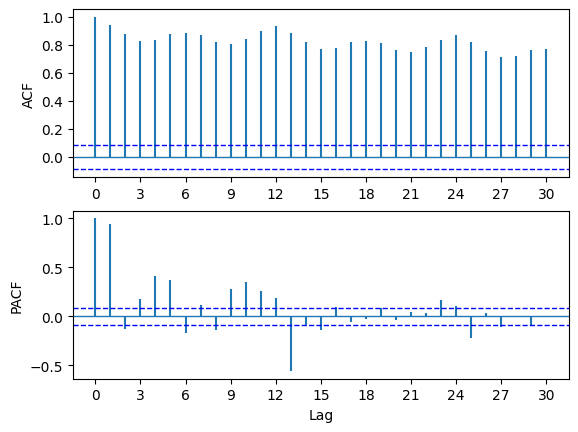

In [69]:
acf_pacf_fig(elec_sqrt, both=True, lag=30)

In [74]:
adfuller(elec_sqrt, autolag='AIC')[1]

0.39590174850289295

Tampah bahwa setelah transformasi BoxCox deret masih tetap tidak stasioner dalam nilai tengah.

<h2> Pertanyaan </h2>

Jika deret tidak stasioner dalam nilaitengah dan ragam, bagaimana urutan penanganan masalah ketidakstasioneran ini? Apakah differencing dahulu lalu transformasi Boxcox atau transformasi Boxcox dahulu lalu differencing?

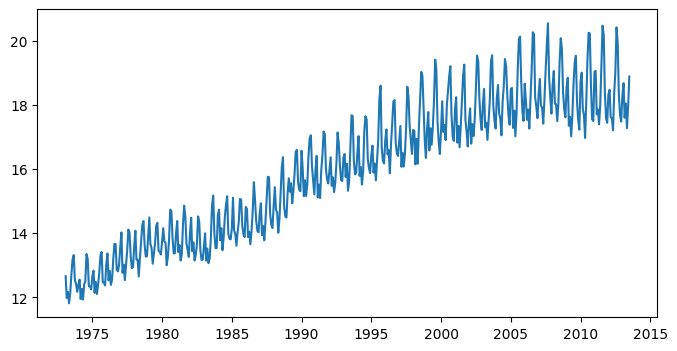

In [75]:
plt.figure(figsize=(8,4))
plt.plot(elec_sqrt)
plt.show()

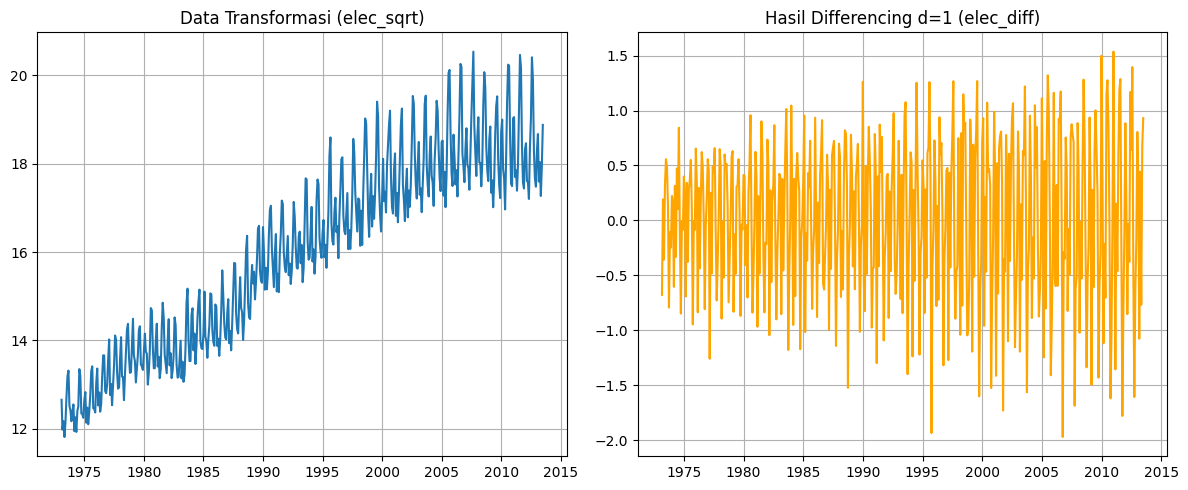

ADF Statistic: -5.4773
p-value      : 0.0000
Kesimpulan: Data sudah stasioner dalam nilaitengah (p-value < 0.05).


In [76]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. Melakukan Diferensiasi Non-Musiman (d=1)
# .diff(1) menghitung selisih Y_t - Y_{t-1}
# .dropna() menghapus nilai NaN di baris pertama akibat proses selisih
elec_diff = elec_sqrt.diff(1).dropna()

# 2. Plot Perbandingan Sebelum dan Sesudah Differencing
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(elec_sqrt)
plt.title('Data Transformasi (elec_sqrt)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(elec_diff, color='orange')
plt.title('Hasil Differencing d=1 (elec_diff)')
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Uji ADF untuk Mengecek Kestasioneran Nilaitengah
adf_result = adfuller(elec_diff, autolag='AIC')
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value      : {adf_result[1]:.4f}')

if adf_result[1] < 0.05:
    print("Kesimpulan: Data sudah stasioner dalam nilaitengah (p-value < 0.05).")
else:
    print(
        "Kesimpulan: Data belum stasioner, mungkin memerlukan diferensiasi musiman (D=1)."
    )